# Diabetes Prediction Using Machine Learning

In [147]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

***Data Collection & Analysis***

**PIMA Diabetes dataset**

In [148]:
# Loading The Diabetes Dataset To a Pandas Dataframe
diabetes_dataset=pd.read_csv("../dataset/diabetes_dataset.csv")

In [149]:
# Print The First 5 Rows Of The Dataset
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [150]:
# Number Of Rows & Columns In The Dataset
diabetes_dataset.shape

(768, 9)

In [151]:
# The Statistical Measures Of The Data
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [152]:
diabetes_dataset['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

**0 --> Non Diabetic**

**1 --> Diabetic**

In [153]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


***Bar Plot For Outcome***

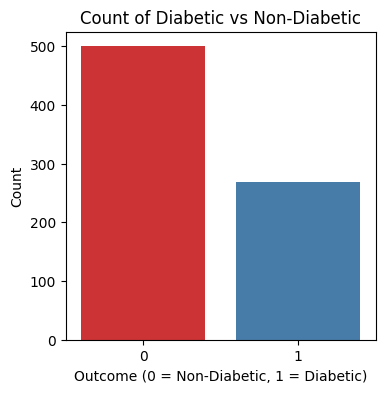

In [154]:
plt.figure(figsize=(4,4))
sns.countplot(x='Outcome', hue='Outcome', data=diabetes_dataset, palette='Set1', legend=False)
plt.title('Count of Diabetic vs Non-Diabetic')
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Count')
plt.show()

***Heatmap Of Correlation Matrix***

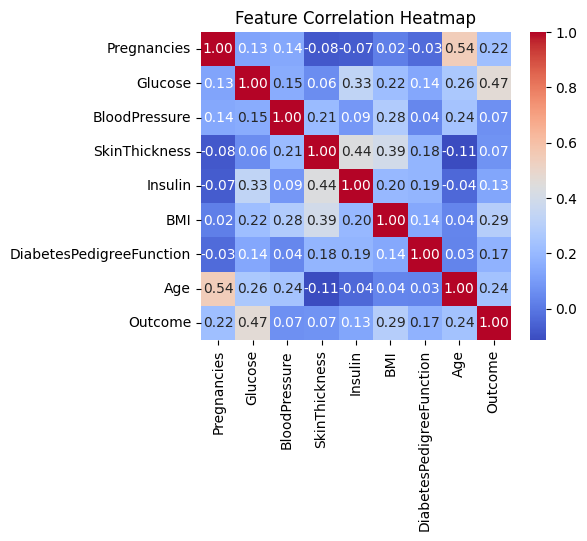

In [155]:
plt.figure(figsize=(5,4))
correlation = diabetes_dataset.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

***Glucose Level Distribution by Outcome***

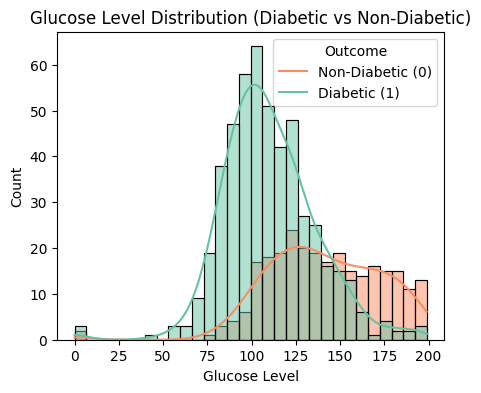

In [156]:
plt.figure(figsize=(5,4))
sns.histplot(data=diabetes_dataset, x='Glucose', hue='Outcome', kde=True, palette='Set2', bins=30)
plt.title('Glucose Level Distribution (Diabetic vs Non-Diabetic)')
plt.xlabel('Glucose Level')
plt.ylabel('Count')
plt.legend(title='Outcome', labels=['Non-Diabetic (0)', 'Diabetic (1)'])
plt.show()

***Box Plot Visualization Of Dataset Features***

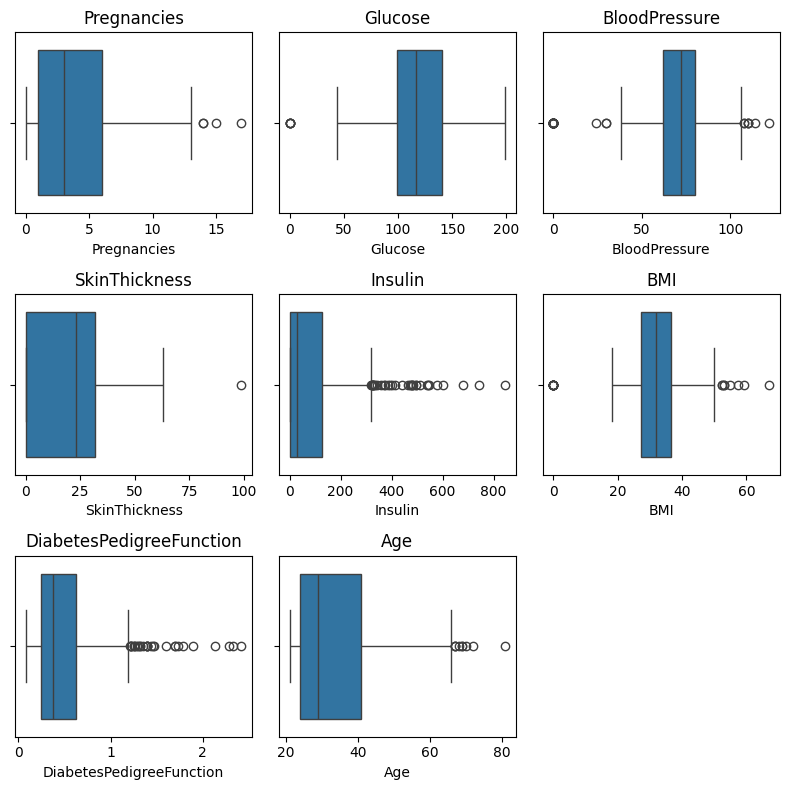

In [157]:
plt.figure(figsize=(8, 8))
for i, col in enumerate(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                         'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=diabetes_dataset[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [158]:
# Separating The Data & Labels
X=diabetes_dataset.drop(columns='Outcome')
Y=diabetes_dataset['Outcome']
print(X.head())
print(Y.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


***Data Standardization***

In [159]:
import pickle
# Create the scaler
scaler = StandardScaler()
# Fit the scaler to your data
scaler.fit(X)
pickle.dump(scaler, open("scaler.pkl","wb"))
print("Scaler saved as 'scaler.pkl'")

# Now transform the data
standardized_data = scaler.transform(X)
# Convert to DataFrame for better readability
standardized_df = pd.DataFrame(standardized_data)
# Print the first 5 rows
print(standardized_df.head())
_ = None

Scaler saved as 'scaler.pkl'
          0         1         2         3         4         5         6  \
0  0.639947  0.848324  0.149641  0.907270 -0.692891  0.204013  0.468492   
1 -0.844885 -1.123396 -0.160546  0.530902 -0.692891 -0.684422 -0.365061   
2  1.233880  1.943724 -0.263941 -1.288212 -0.692891 -1.103255  0.604397   
3 -0.844885 -0.998208 -0.160546  0.154533  0.123302 -0.494043 -0.920763   
4 -1.141852  0.504055 -1.504687  0.907270  0.765836  1.409746  5.484909   

          7  
0  1.425995  
1 -0.190672  
2 -0.105584  
3 -1.041549  
4 -0.020496  


In [160]:
X=standardized_data
Y=diabetes_dataset['Outcome']
print(X[:5])
print(Y[:5])

[[ 0.63994726  0.84832379  0.14964075  0.90726993 -0.69289057  0.20401277
   0.46849198  1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575  0.53090156 -0.69289057 -0.68442195
  -0.36506078 -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 -1.28821221 -0.69289057 -1.10325546
   0.60439732 -0.10558415]
 [-0.84488505 -0.99820778 -0.16054575  0.15453319  0.12330164 -0.49404308
  -0.92076261 -1.04154944]
 [-1.14185152  0.5040552  -1.50468724  0.90726993  0.76583594  1.4097456
   5.4849091  -0.0204964 ]]
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [161]:
# Train Test Split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)
print(X.shape,X_train.shape,X_test.shape)

(768, 8) (614, 8) (154, 8)


***Training The Model***

In [162]:
classifier=svm.SVC(kernel='linear')
# Training The Support Vector Machine Classifier
classifier.fit(X_train,Y_train);

In [163]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.svm import SVC
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)
# classifier = SVC(kernel='linear')
# classifier.fit(X_train_scaled, Y_train)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='linear'))
])

pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


# Model Caching

In [164]:
import pickle

filename="diabetes_model.pkl"
with open(filename, 'wb') as file:
    pickle.dump(pipeline, file)

In [165]:
import pickle
filename="diabetes_model.pkl"
with open(filename, 'rb') as file:
    loaded_model = pickle.load(file)

In [166]:
# Accuracy Of Test Data
X_test_prediction=loaded_model.predict(X_test)
test_data_accuracy=accuracy_score(Y_test,X_test_prediction)
print("Accuracy on Test Data: ",test_data_accuracy)

Accuracy on Test Data:  0.7727272727272727


In [167]:
import pandas as pd
import numpy as np
# Example Input:
# input_data = (1,95,70,20,80,24.5,0.2,25) # non-diabetic
input_data = (6,148,72,35,0,33.6,0.627,50) # diabetic
# Feature Names 
feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
# Convert Input To DataFrame
input_df = np.array(input_data).reshape(1,-1)
input_scaled=scaler.transform(input_df)
prediction = loaded_model.predict(input_scaled)
print("Prediction (0 = Not Diabetic, 1 = Diabetic):\n", prediction)

if prediction[0] == 0:
    print("The person is not Diabetic.")
else:
    print("The person is Diabetic.")


Prediction (0 = Not Diabetic, 1 = Diabetic):
 [1]
The person is Diabetic.


/Users/shouvikbajpayee/Projects/all-about-cs/env/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


***Model Evalution***

In [168]:
# # Accuracy Of Training Data
# X_train_prediction=classifier.predict(X_train)
# training_data_accuracy=accuracy_score(X_train_prediction,Y_train)
# print("Accuracy on Training Data: ",training_data_accuracy)

In [169]:
# # Accuracy Of Test Data
# X_test_prediction=classifier.predict(X_test)
# test_data_accuracy=accuracy_score(Y_test,X_test_prediction)
# print("Accuracy on Test Data: ",test_data_accuracy)

***Predictive System***

In [170]:
# # Example Input:
# # input_data = (1,95,70,20,80,24.5,0.2,25) # non-diabetic
# input_data = (6,148,72,35,0,33.6,0.627,50) # diabetic
# # Feature Names 
# feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
#                  'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
# # Convert Input To DataFrame
# input_df = pd.DataFrame([input_data], columns=feature_names)
# std_data = scaler.transform(input_df)
# prediction = classifier.predict(std_data)
# print("Standardized Input:\n", std_data)
# print("Prediction (0 = Not Diabetic, 1 = Diabetic):\n", prediction)

# if prediction[0] == 0:
#     print("The person is not Diabetic.")
# else:
#     print("The person is Diabetic.")
